In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Understanding Data

In [2]:
data = pd.read_csv("salaries.csv")
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Customer Success Manager,57000,EUR,60000,NL,50,NL,L
1,2025,SE,FT,Engineer,165000,USD,165000,US,0,US,M
2,2025,SE,FT,Engineer,109000,USD,109000,US,0,US,M
3,2025,SE,FT,Applied Scientist,294000,USD,294000,US,0,US,M
4,2025,SE,FT,Applied Scientist,137600,USD,137600,US,0,US,M


In [3]:
data.describe(include="all")

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,88584.000000,88584,88584,88584,8.858400e+04,88584,88584.000000,88584,88584.000000,88584,88584
unique,NaN,4,4,312,NaN,26,NaN,96,NaN,90,3
top,NaN,SE,FT,Data Scientist,NaN,USD,NaN,US,NaN,US,M
freq,NaN,51596,88111,13156,NaN,83994,NaN,79705,NaN,79762,85667
mean,2024.034758,NaN,NaN,NaN,1.619323e+05,NaN,157567.798417,NaN,21.286011,NaN,NaN
std,0.620370,NaN,NaN,NaN,1.965317e+05,NaN,73531.373158,NaN,40.831018,NaN,NaN
min,2020.000000,NaN,NaN,NaN,1.400000e+04,NaN,15000.000000,NaN,0.000000,NaN,NaN
25%,2024.000000,NaN,NaN,NaN,1.060000e+05,NaN,106097.250000,NaN,0.000000,NaN,NaN
50%,2024.000000,NaN,NaN,NaN,1.470000e+05,NaN,146307.000000,NaN,0.000000,NaN,NaN
75%,2024.000000,NaN,NaN,NaN,1.995000e+05,NaN,198600.000000,NaN,0.000000,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88584 entries, 0 to 88583
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           88584 non-null  int64 
 1   experience_level    88584 non-null  object
 2   employment_type     88584 non-null  object
 3   job_title           88584 non-null  object
 4   salary              88584 non-null  int64 
 5   salary_currency     88584 non-null  object
 6   salary_in_usd       88584 non-null  int64 
 7   employee_residence  88584 non-null  object
 8   remote_ratio        88584 non-null  int64 
 9   company_location    88584 non-null  object
 10  company_size        88584 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.4+ MB


In [5]:
data["job_title"].unique()

array(['Customer Success Manager', 'Engineer', 'Applied Scientist',
       'Data Analyst', 'Software Development Engineer',
       'Research Scientist', 'Data Scientist', 'Platform Engineer',
       'Computational Biologist', 'AI Data Scientist',
       'Admin & Data Analyst', 'Cloud Engineer',
       'Data Management Specialist', 'Data Product Owner',
       'Software Engineer', 'Machine Learning Engineer', 'Associate',
       'Data Engineer', 'Product Manager', 'Data Operations Engineer',
       'Business Intelligence Engineer', 'Research Engineer',
       'Analytics Engineer', 'Analyst', 'Actuarial Analyst', 'Manager',
       'Architect', 'Software Developer', 'Member of Technical Staff',
       'BI Analyst', 'AI Engineer', 'Data Governance Analyst',
       'Developer', 'DevOps Engineer', 'Business Intelligence Analyst',
       'Site Reliability Engineer', 'Computational Scientist',
       'Data Management Analyst', 'Data and Reporting Analyst',
       'Solution Architect', 'Data Re

# 2. Feature Engineering

In [6]:
CATEGORY_RULES = [
    # --- Most spesific roles ---
    ("Business Intelligence", [
        "business intelligence", "bi analyst", "bi developer",
        "bi engineer", "power bi", "tableau", "dashboard"
    ]),
    
    ("Machine Learning Engineer", [
        "machine learning engineer", "ml engineer",
        "machine learning software", "deep learning"
    ]),
    
    ("AI Engineer / Specialist", [
        "ai engineer", "ai developer", "artificial intelligence",
        "genai", "prompt engineer"
    ]),
    
    ("MLOps Engineer", [
        "mlops", "ml infrastructure", "ml platform"
    ]),
    
    ("Analytics Engineer", [
        "analytics engineer"
    ]),
    
    ("Data Scientist", [
        "data scientist", "applied data scientist",
        "decision scientist"
    ]),
    
    ("Research Scientist", [
        "research scientist", "researcher",
        "applied research", "postdoctoral"
    ]),
    
    ("Data Engineer", [
        "data engineer", "big data engineer",
        "etl", "pipeline", "databricks", "cloud data"
    ]),
    
    ("Data Architect", [
        "data architect", "big data architect", "cloud data architect"
    ]),
    
    ("Platform / Infrastructure Engineer", [
        "platform engineer", "infrastructure engineer",
        "systems engineer"
    ]),
    
    ("DevOps / SRE", [
        "devops", "site reliability", "sre"
    ]),
    
    ("Software Engineer / Developer", [
        "software engineer", "software developer",
        "backend developer", "full stack", "frontend engineer",
        "application developer", "software", "python"
    ]),
    
    # --- Management & Leadersip ---
    ("Management / Lead", [
        "head", "lead", "manager", "director", "principal"
    ]),
    
    # --- General / less spesific roles ---
    ("Visualization Specialist", [
        "visualization", "data visualization"
    ]),
    
    ("Quantitative / Actuarial", [
        "quantitative", "actuarial", 
    ]),
    
    ("Data Governance / Quality", [
        "data governance", "data quality",
        "data integrity", "compliance"
    ]),
    
    ("Product & Strategy (Data/AI)", [
        "product manager", "product owner",
        "data product", "ai product"
    ]),
    
    ("Consultant / Specialist", [
        "consultant", "specialist"
    ]),
    
    ("Data Analyst", [
        "data analyst", "analyst",
        "reporting", "insight", "analytics analyst"
    ]),
]

In [7]:
def categorize_job_title(title: str) -> str:
    if pd.isna(title):
        return "Other"
    
    title = title.lower().strip()
    
    for category, keywords in CATEGORY_RULES:
        if any(keyword in title for keyword in keywords):
            return category
    
    return "Other"

In [8]:
data["job_category"] = data["job_title"].apply(categorize_job_title)

In [9]:
mapping = {
    "EN": "Junior",
    "MI": "Mid Level",
    "SE": "Senior",
    "EX": "Executive Level"
}

data["experience_level"] = data["experience_level"].map(mapping)

In [10]:
mapping = {
    "FT": "Full Time",
    "PT": "Part Time",
    "CT": "Contract",
    "FL": "Freelance"
}

data["employment_type"] = data["employment_type"].map(mapping)

In [11]:
mapping = {
    "S": "Small",
    "M": "Medium",
    "L": "Large"
}

data["company_size"] = data["company_size"].map(mapping)

In [12]:
data.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category
0,2025,Mid Level,Full Time,Customer Success Manager,57000,EUR,60000,NL,50,NL,Large,Management / Lead
1,2025,Senior,Full Time,Engineer,165000,USD,165000,US,0,US,Medium,Other
2,2025,Senior,Full Time,Engineer,109000,USD,109000,US,0,US,Medium,Other
3,2025,Senior,Full Time,Applied Scientist,294000,USD,294000,US,0,US,Medium,Other
4,2025,Senior,Full Time,Applied Scientist,137600,USD,137600,US,0,US,Medium,Other
5,2025,Junior,Full Time,Data Analyst,82000,USD,82000,US,0,US,Medium,Data Analyst
6,2025,Junior,Full Time,Data Analyst,44000,USD,44000,US,0,US,Medium,Data Analyst
7,2025,Senior,Full Time,Software Development Engineer,149800,USD,149800,US,0,US,Large,Software Engineer / Developer
8,2025,Senior,Full Time,Software Development Engineer,89700,USD,89700,US,0,US,Large,Software Engineer / Developer
9,2025,Senior,Full Time,Research Scientist,200000,USD,200000,US,0,US,Medium,Research Scientist


# 3. Data Visualization

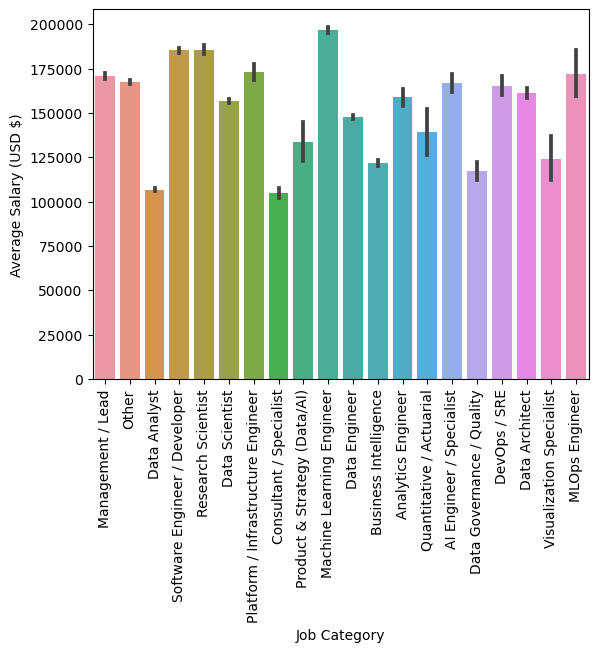

In [13]:
sns.barplot(
    data=data,
    x="job_category",
    y="salary_in_usd"
)

plt.xlabel("Job Category")
plt.ylabel("Average Salary (USD $)")
plt.xticks(rotation=90)
plt.show()

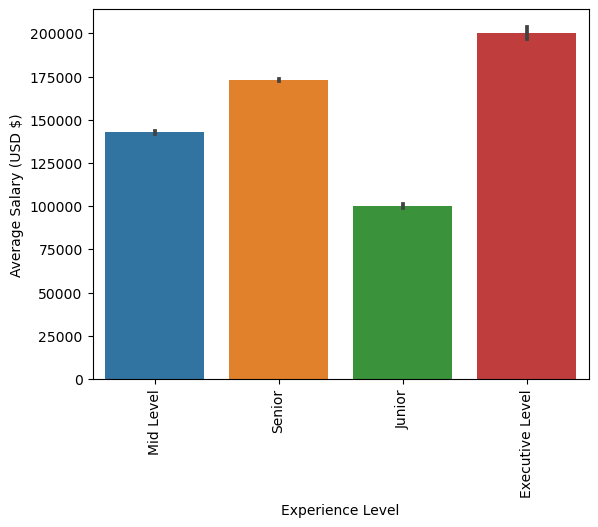

In [14]:
sns.barplot(
    data=data,
    x="experience_level",
    y="salary_in_usd"
)

plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD $)")
plt.xticks(rotation=90)
plt.show()

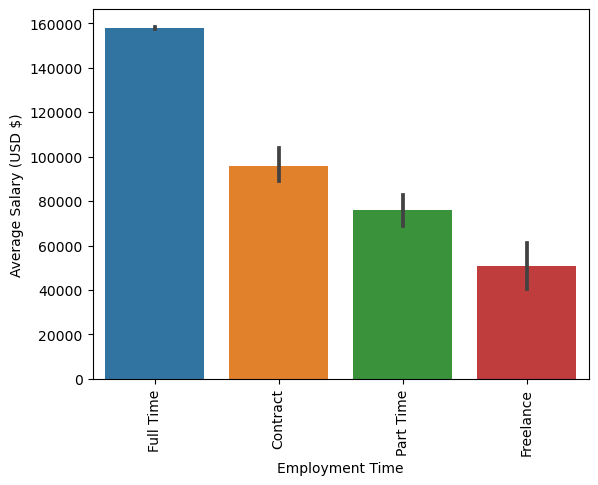

In [15]:
sns.barplot(
    data=data,
    x="employment_type",
    y="salary_in_usd"
)

plt.xlabel("Employment Time")
plt.ylabel("Average Salary (USD $)")
plt.xticks(rotation=90)
plt.show()

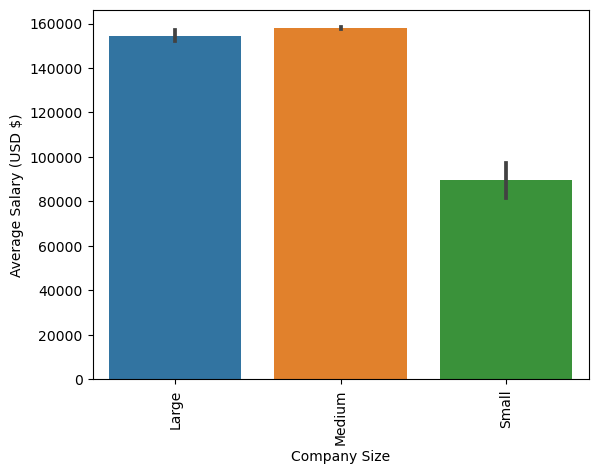

In [16]:
sns.barplot(
    data=data,
    x="company_size",
    y="salary_in_usd"
)

plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD $)")
plt.xticks(rotation=90)
plt.show()

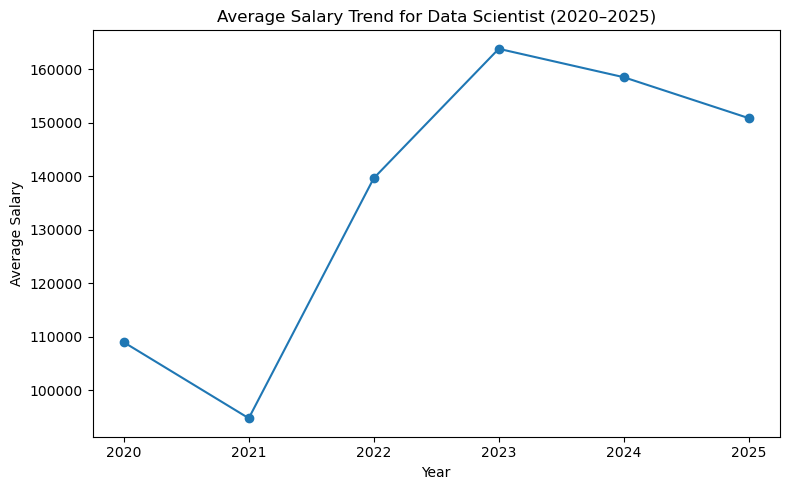

In [17]:
ROLE = "Data Scientist"

df_role = data[data["job_title"] == ROLE]

avg_salary_by_year = (
    df_role
    .groupby("work_year")["salary_in_usd"]
    .mean()
    .reset_index()
    .sort_values("work_year")
)

plt.figure(figsize=(8, 5))

plt.plot(
    avg_salary_by_year["work_year"],
    avg_salary_by_year["salary_in_usd"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Salary")
plt.title(f"Average Salary Trend for {ROLE} (2020–2025)")

plt.xticks(avg_salary_by_year["work_year"])
plt.tight_layout()
plt.show()

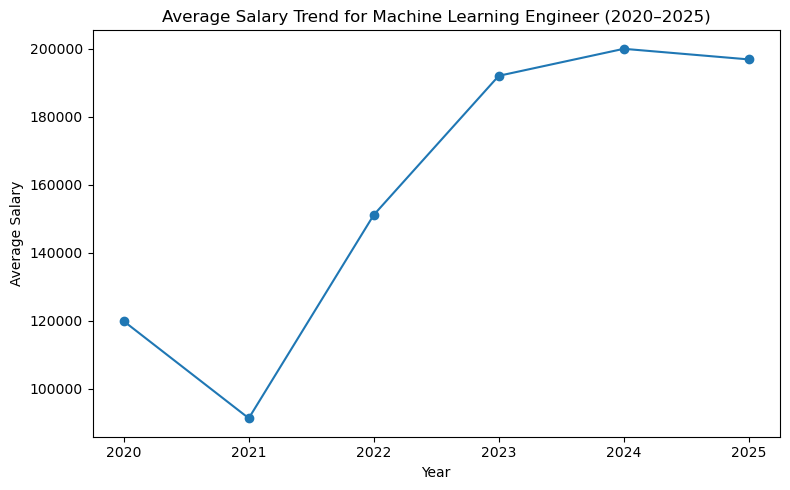

In [18]:
ROLE = "Machine Learning Engineer"

df_role = data[data["job_title"] == ROLE]

avg_salary_by_year = (
    df_role
    .groupby("work_year")["salary_in_usd"]
    .mean()
    .reset_index()
    .sort_values("work_year")
)

plt.figure(figsize=(8, 5))

plt.plot(
    avg_salary_by_year["work_year"],
    avg_salary_by_year["salary_in_usd"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Salary")
plt.title(f"Average Salary Trend for {ROLE} (2020–2025)")

plt.xticks(avg_salary_by_year["work_year"])
plt.tight_layout()
plt.show()

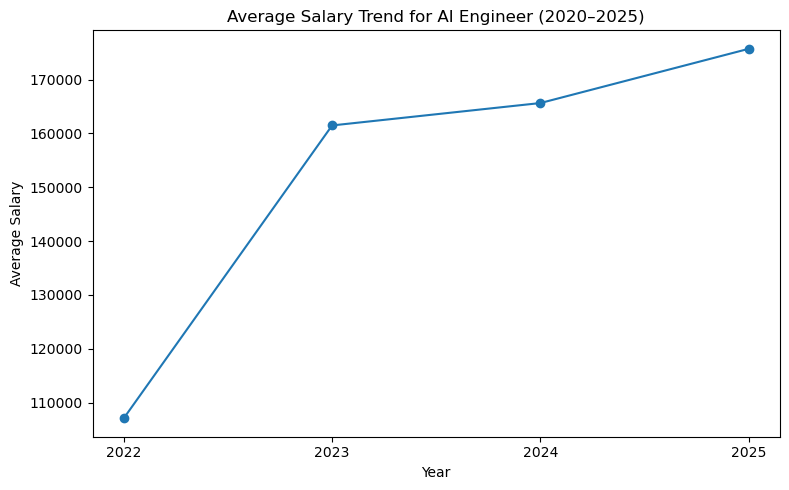

In [19]:
ROLE = "AI Engineer"

df_role = data[data["job_title"] == ROLE]

avg_salary_by_year = (
    df_role
    .groupby("work_year")["salary_in_usd"]
    .mean()
    .reset_index()
    .sort_values("work_year")
)

plt.figure(figsize=(8, 5))

plt.plot(
    avg_salary_by_year["work_year"],
    avg_salary_by_year["salary_in_usd"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Salary")
plt.title(f"Average Salary Trend for {ROLE} (2020–2025)")

plt.xticks(avg_salary_by_year["work_year"])
plt.tight_layout()
plt.show()

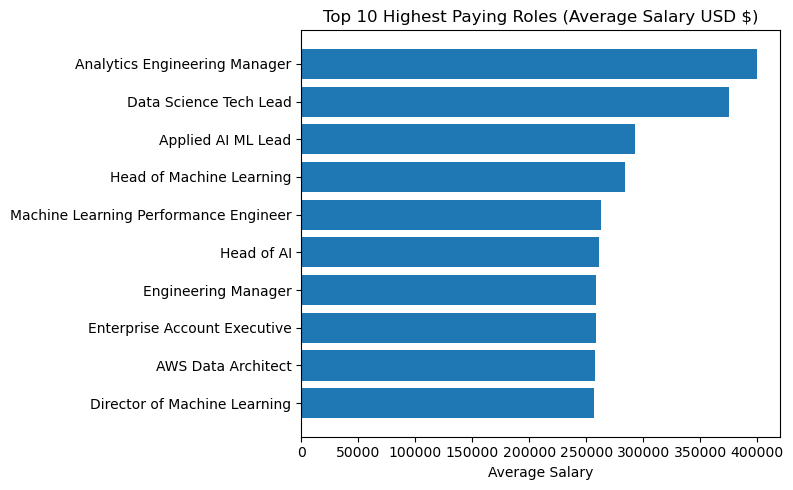

In [20]:
top10_jobs = (
    data.groupby("job_title")["salary_in_usd"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(8, 5))

plt.barh(
    top10_jobs["job_title"],
    top10_jobs["salary_in_usd"]
)

plt.gca().invert_yaxis()
plt.xlabel("Average Salary")
plt.title("Top 10 Highest Paying Roles (Average Salary USD $)")

plt.tight_layout()
plt.show()